# Lab 1 — Obrada slike i prostori boja

Rješenja pet zadataka iz laboratorijske vježbe, uz kratka objašnjenja na hrvatskom.

**Izvor zadataka i slika:** [pui-sum-rv/lab1](https://github.com/pui-sum-rv/lab1). Kao referenca pregledana je dostavljena bilježnica kolegice iz repozitorija [sabljicmija/Racunalni-vid-LV](https://github.com/sabljicmija/Racunalni-vid-LV). Ova verzija sadrži novo napisana rješenja i objašnjenja pripremljena uz pomoć ChatGPT-a.

## Pokretanje
Pokreni sve ćelije redom. Potrebni su Python, NumPy, OpenCV i Matplotlib (u Google Colabu obično su dostupni). Za lokalnu instalaciju: `pip install numpy opencv-python matplotlib`.

Bilježnica prvo traži `images/peppers.png`, zatim `images/pepper.bmp`. Ako ih nema, preuzima `pepper.bmp` iz izvornog repozitorija. Tada je potreban pristup internetu. Naziv u tekstu izvornog zadatka razlikuje se od naziva BMP datoteke dostupne u repozitoriju.


Učitana datoteka: images/pepper.bmp; dimenzije (visina, širina, kanali): (512, 512, 3)


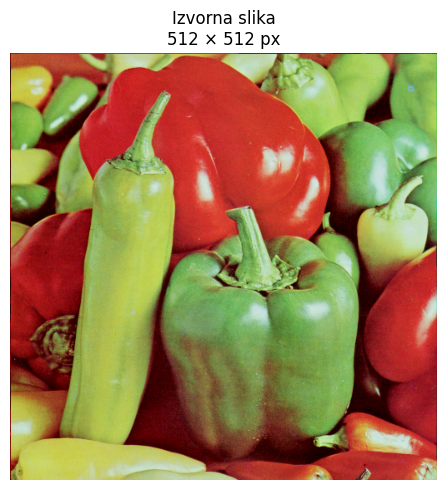

In [1]:
from pathlib import Path
from urllib.request import urlopen
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

kandidati = [Path("images/peppers.png"), Path("images/pepper.bmp")]
putanja = next((p for p in kandidati if p.is_file()), None)
if putanja is None:
    putanja = kandidati[1]
    putanja.parent.mkdir(parents=True, exist_ok=True)
    adresa = "https://raw.githubusercontent.com/pui-sum-rv/lab1/main/images/pepper.bmp"
    with urlopen(adresa, timeout=30) as odgovor:
        putanja.write_bytes(odgovor.read())

slika_bgr = cv.imread(str(putanja))
if slika_bgr is None:
    raise ValueError(f"Nije moguće učitati sliku: {putanja}")
slika_rgb = cv.cvtColor(slika_bgr, cv.COLOR_BGR2RGB)

def prikazi(slike, naslovi):
    fig, osi = plt.subplots(1, len(slike), figsize=(5 * len(slike), 5), squeeze=False)
    for os, slika, naslov in zip(osi[0], slike, naslovi):
        os.imshow(slika)
        os.set_title(f"{naslov}\n{slika.shape[1]} × {slika.shape[0]} px")
        os.axis("off")
    plt.tight_layout()
    plt.show()

print(f"Učitana datoteka: {putanja}; dimenzije (visina, širina, kanali): {slika_rgb.shape}")
prikazi([slika_rgb], ["Izvorna slika"])


## 1. Izdvajanje kanala boje
**Zadatak:** Prikazati tri slike, po jednu za svaki kanal. Preostala dva kanala postaviti na nulu.

Nakon pretvorbe u RGB, indeksi 0, 1 i 2 označavaju crveni, zeleni i plavi kanal. Za svaki kanal stvaramo crnu sliku jednakih dimenzija i kopiramo samo odabrani kanal. To nije isto što i pretvorba u sivu ili binarnu sliku.


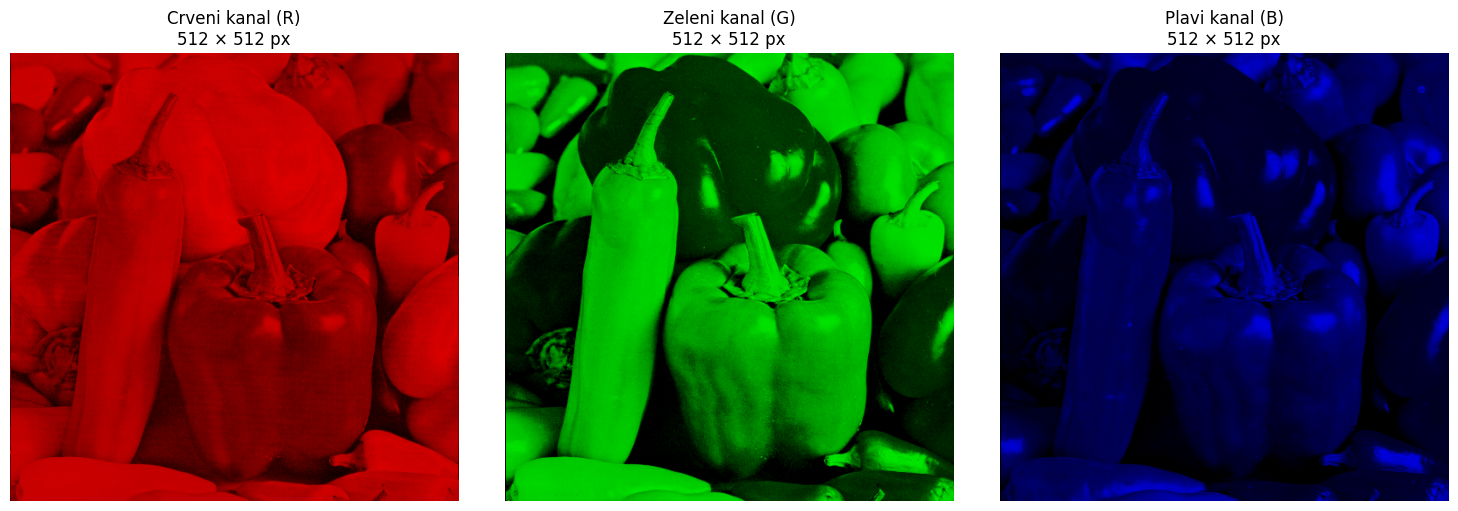

In [2]:
kanali = []
for indeks in range(3):
    izdvojeni = np.zeros_like(slika_rgb)
    izdvojeni[:, :, indeks] = slika_rgb[:, :, indeks]
    kanali.append(izdvojeni)
prikazi(kanali, ["Crveni kanal (R)", "Zeleni kanal (G)", "Plavi kanal (B)"])


## 2. Obrub širine 10 piksela
**Zadatak:** Dodati obrub od 10 piksela sa svake strane.

Koristimo konstantni crni obrub. Širina i visina povećavaju se svaka za 20 piksela jer se dodaje po 10 piksela na dvije suprotne strane.


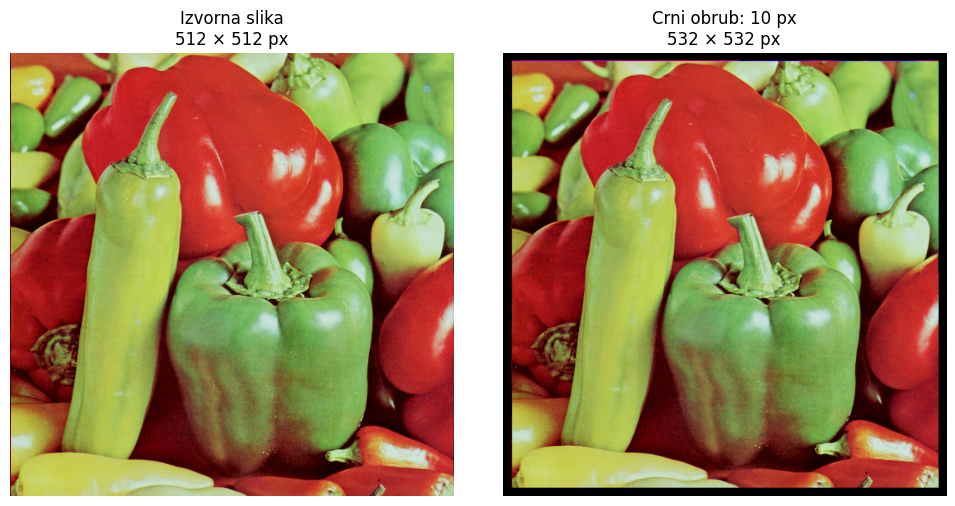

In [3]:
obrub = 10
slika_s_obrubom = cv.copyMakeBorder(
    slika_rgb, obrub, obrub, obrub, obrub,
    borderType=cv.BORDER_CONSTANT, value=(0, 0, 0)
)
prikazi([slika_rgb, slika_s_obrubom], ["Izvorna slika", "Crni obrub: 10 px"])


## 3. Uzimanje svakog drugog piksela
**Zadatak:** Napraviti sliku s polovicom redaka, sliku s polovicom stupaca te sliku s polovicom obojega.

NumPy zapis `::2` odabire indekse 0, 2, 4, … Prva dimenzija označava retke (visinu), druga stupce (širinu). Ovo je poduzorkovanje bez interpolacije; uklanjanje samo redaka ili samo stupaca mijenja omjer stranica. Kod neparnih dimenzija ostaje broj elemenata zaokružen prema gore.


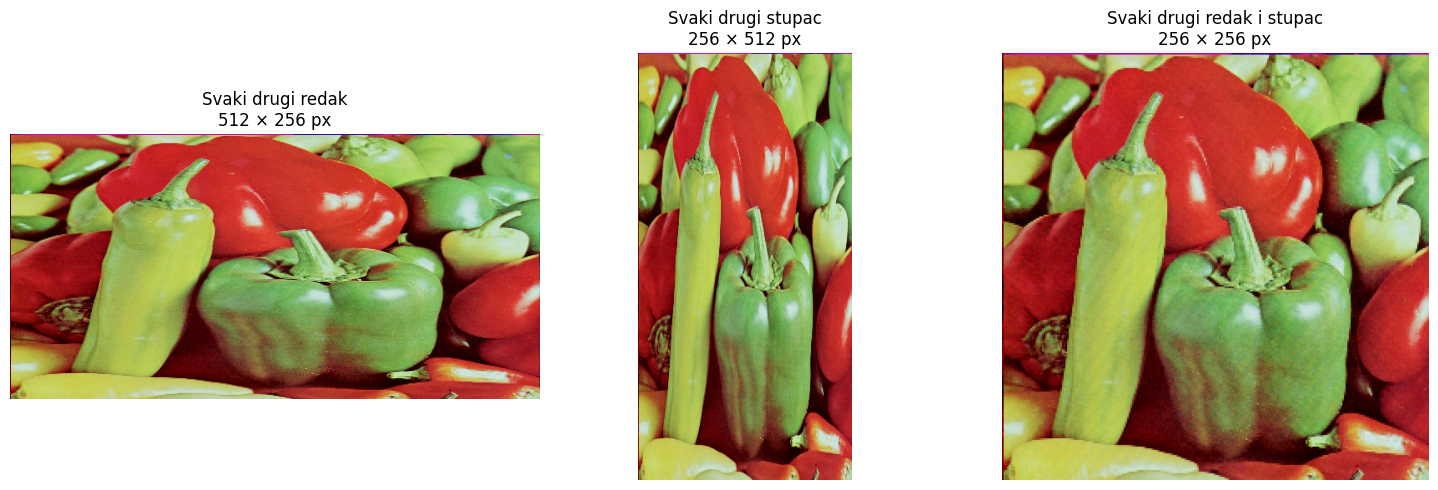

In [4]:
pola_redaka = slika_rgb[::2, :, :]
pola_stupaca = slika_rgb[:, ::2, :]
pola_obojega = slika_rgb[::2, ::2, :]
prikazi(
    [pola_redaka, pola_stupaca, pola_obojega],
    ["Svaki drugi redak", "Svaki drugi stupac", "Svaki drugi redak i stupac"]
)


## 4. HSV: povećanje H kanala za 30
**Zadatak:** Pretvoriti sliku paprika u HSV, svakom pikselu dodati 30 na H kanal, zatim pretvoriti u RGB i prikazati.

H je nijansa, S zasićenost, a V vrijednost (svjetlina). Za 8-bitni OpenCV HSV, H je u rasponu 0–179. Zato nakon zbrajanja koristimo modulo 180. Pomak za 30 jedinica odgovara približno 60° na krugu nijansi. Privremena pretvorba u `int16` sprječava preljev pri računanju; S i V ostaju isti.


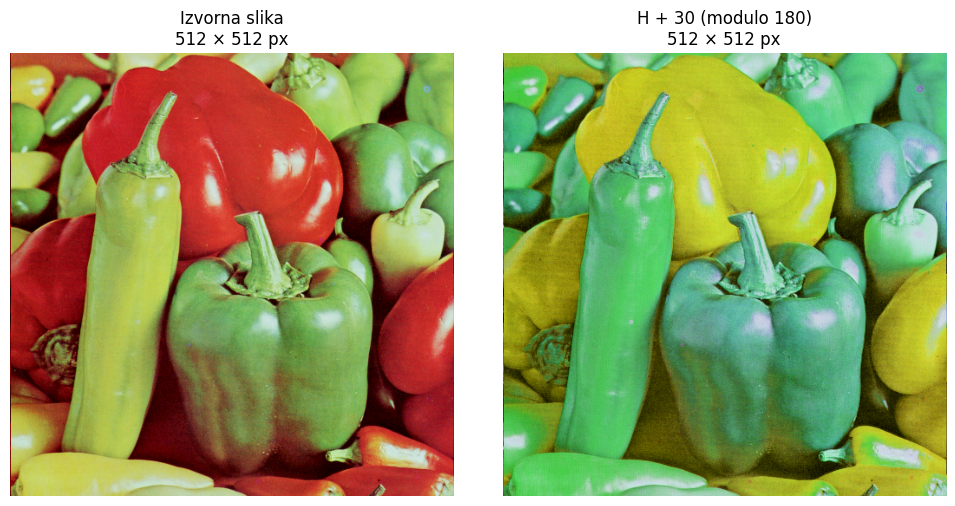

In [5]:
izvorni_hsv = cv.cvtColor(slika_bgr, cv.COLOR_BGR2HSV)
pomaknuti_hsv = izvorni_hsv.copy()
pomaknuti_hsv[:, :, 0] = (
    (izvorni_hsv[:, :, 0].astype(np.int16) + 30) % 180
).astype(np.uint8)
pomaknuta_rgb = cv.cvtColor(pomaknuti_hsv, cv.COLOR_HSV2RGB)
prikazi([slika_rgb, pomaknuta_rgb], ["Izvorna slika", "H + 30 (modulo 180)"])


## 5. HSV: postavljanje H kanala na nulu
**Zadatak:** U HSV slici svim pikselima postaviti H na 0, vratiti sliku u RGB i prikazati.

Polazimo ponovno od izvorne slike. H = 0 odgovara crvenoj nijansi. S i V ostaju isti, pa pikseli zadržavaju različitu zasićenost i svjetlinu. Pikseli sa S = 0 ostaju sivi, a oni s V = 0 crni.


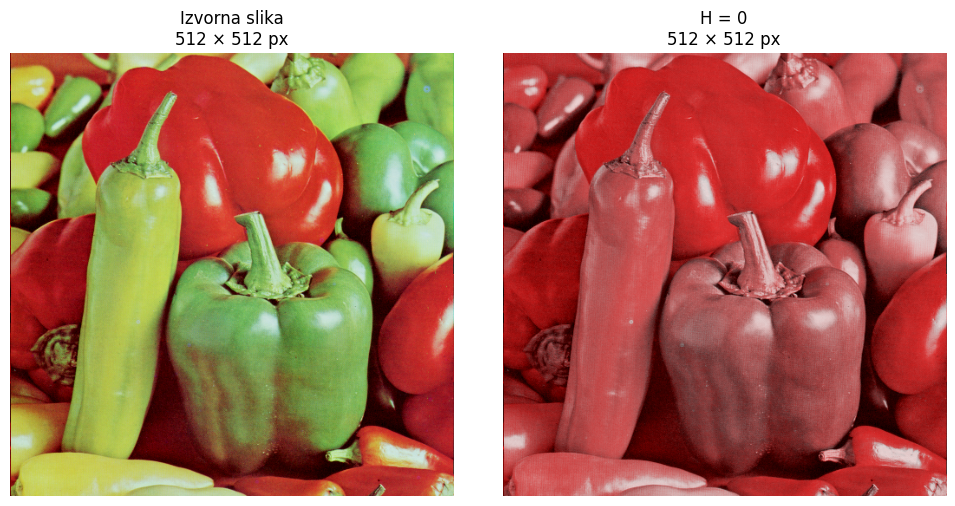

In [6]:
crveni_hsv = izvorni_hsv.copy()
crveni_hsv[:, :, 0] = 0
crvena_rgb = cv.cvtColor(crveni_hsv, cv.COLOR_HSV2RGB)
prikazi([slika_rgb, crvena_rgb], ["Izvorna slika", "H = 0"])


## Zaključak
Izdvajanje RGB kanala pokazuje doprinos pojedine komponente boje. Obrub proširuje sliku bez promjene izvornih piksela. Poduzorkovanje smanjuje broj piksela, ali može ukloniti detalje. U HSV prostoru možemo promijeniti nijansu uz očuvanje kanala S i V.

Prije predaje pokreni sve ćelije, prouči rezultate i provjeri pravila kolegija o korištenju izvora i AI pomoći. Za GitHub spremi ovu `.ipynb` datoteku u svoj repozitorij; spremljeni izlazi omogućuju pregled rezultata bez pokretanja koda.
